# Análisis Exploratorio — Disaster Tweets

Dataset: *Natural Language Processing with Disaster Tweets* (Kaggle). Objetivo: entender los datos antes de clasificar si un tweet describe un desastre real (`target=1`) o no (`target=0`).

Usamos dos versiones del texto:
- **Crudo** (`data/raw/train.csv`) para metadatos, largos y cruces con `keyword`/`location`.
- **Limpio** (`data/cleaned/train_cleaned.csv`, generado por `notebooks/preprocesamiento_y_limpieza.ipynb`) para frecuencias de palabras y nubes de palabras — sin esto, las nubes quedarían dominadas por stopwords (`the`, `a`, `to`).

In [2]:
import sys
sys.path.append('..')

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.eda import word_frequencies, plot_top_words, make_wordcloud, shared_words, text_stats

sns.set_theme(style='whitegrid')

raw = pd.read_csv('../data/raw/train.csv')
clean = pd.read_csv('../data/cleaned/train_cleaned.csv')


## 1. Carga y forma del dataset

In [3]:
print(raw.shape)
print(raw.dtypes)
raw.head()


(7613, 5)
id          int64
keyword       str
location      str
text          str
target      int64
dtype: object


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


7,613 tweets, 5 columnas. `id` y `target` son numéricas; `keyword`, `location` y `text` son texto libre.

## 2. Nulos y balance de clases

In [4]:
nulls = raw.isna().mean().sort_values(ascending=False) * 100
print(nulls.round(2))


location    33.27
keyword      0.80
id           0.00
text         0.00
target       0.00
dtype: float64


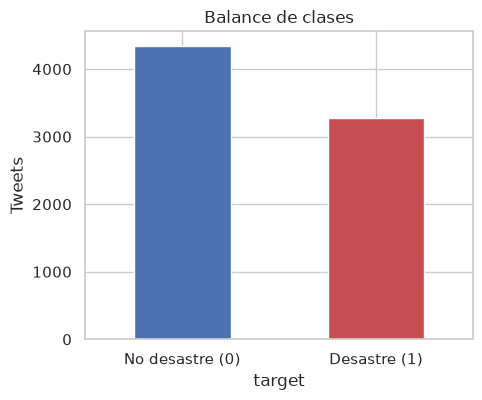

target
0    57.0
1    43.0
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
raw['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['No desastre (0)', 'Desastre (1)'], rotation=0)
ax.set_title('Balance de clases')
ax.set_ylabel('Tweets')
plt.show()

print(raw['target'].value_counts(normalize=True).round(3) * 100)


`location` tiene ~33% de nulos (campo opcional en Twitter, texto libre sin estandarizar). `keyword` casi no tiene nulos (~0.8%). Las clases están moderadamente desbalanceadas (~57% no-desastre / 43% desastre), suficientemente parejo como para no requerir resampleo agresivo en el modelado posterior.

## 3. Cruces de variables

### 3.1 `keyword` vs `target`
¿Qué keywords son más predictivas de desastre real?

In [6]:
kw_rate = raw.dropna(subset=['keyword']).groupby('keyword')['target'].agg(['mean', 'count'])
kw_rate = kw_rate[kw_rate['count'] >= 10]  # evitar keywords con muy pocas observaciones

print('Top 10 keywords MÁS asociadas a desastre real:')
print(kw_rate.sort_values('mean', ascending=False).head(10))

print('\nTop 10 keywords MENOS asociadas a desastre real:')
print(kw_rate.sort_values('mean').head(10))


Top 10 keywords MÁS asociadas a desastre real:
                       mean  count
keyword                           
debris             1.000000     37
derailment         1.000000     39
wreckage           1.000000     39
outbreak           0.975000     40
oil%20spill        0.973684     38
typhoon            0.973684     38
suicide%20bombing  0.969697     33
suicide%20bomber   0.967742     31
bombing            0.931034     29
suicide%20bomb     0.914286     35

Top 10 keywords MENOS asociadas a desastre real:
                 mean  count
keyword                     
aftershock   0.000000     34
body%20bags  0.024390     41
ruin         0.027027     37
blazing      0.029412     34
body%20bag   0.030303     33
electrocute  0.031250     32
screaming    0.055556     36
traumatised  0.057143     35
panicking    0.060606     33
blew%20up    0.060606     33


Keywords como `derailment` o `wreckage` casi siempre acompañan un desastre real; otras como `aftershock` o `body%20bags` (usadas también en sentido figurado o en música/noticias de espectáculo) casi nunca lo son. Esto confirma que `keyword`, aunque parcial, es una señal útil para el modelo.

### 3.2 `location` vs `target`
`location` es texto libre (no estandarizado: "USA", "United States", "New York, NY" conviven), por eso es ruidosa como variable directa. Aun así, revisamos las ubicaciones más frecuentes.

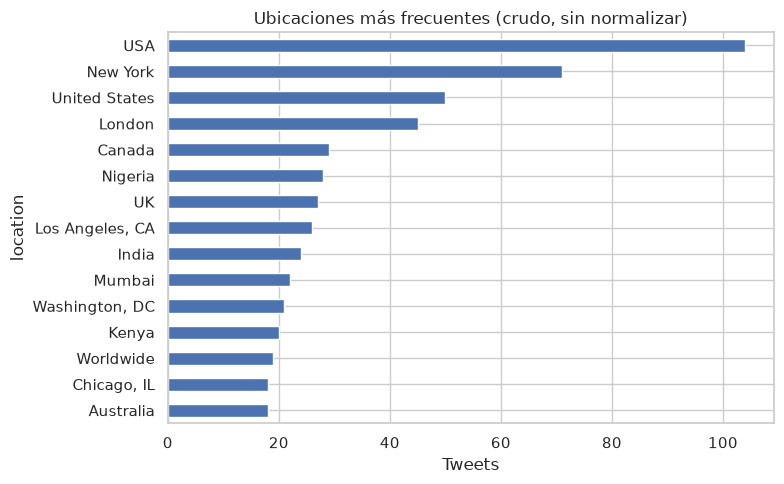

In [7]:
top_locations = raw['location'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 5))
top_locations.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Ubicaciones más frecuentes (crudo, sin normalizar)')
ax.set_xlabel('Tweets')
plt.tight_layout()
plt.show()


"USA" y "New York" dominan, pero hay muchas variantes del mismo lugar ("United States", "NYC") y entradas no geográficas ("Worldwide", "Everywhere"). `location` necesitaría normalización (geocoding o mapeo manual) para ser útil; no se usa como feature directo en este análisis.

### 3.3 Largo del texto vs `target`

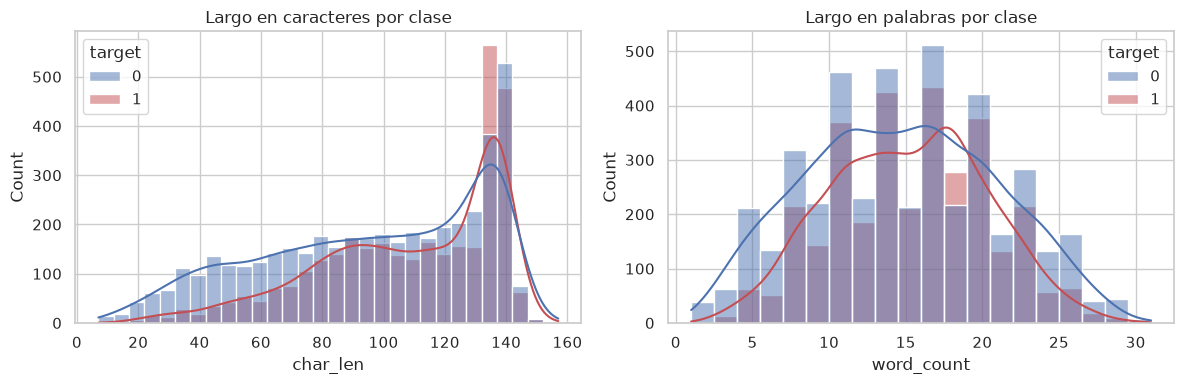

        char_len  word_count
target                      
0           95.7        14.7
1          108.1        15.2


In [8]:
raw_stats = text_stats(raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=raw_stats, x='char_len', hue='target', bins=30, kde=True, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Largo en caracteres por clase')
sns.histplot(data=raw_stats, x='word_count', hue='target', bins=20, kde=True, ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Largo en palabras por clase')
plt.tight_layout()
plt.show()

print(raw_stats.groupby('target')[['char_len', 'word_count']].mean().round(1))


Los tweets de desastre real tienden a ser ligeramente más largos en promedio, consistente con reportes informativos (más detalles: lugar, tipo de evento) frente a comentarios casuales o metafóricos que suelen ser más cortos.

## 4. Palabras más frecuentes por categoría
Sobre texto **limpio** (sin stopwords, URLs, puntuación).

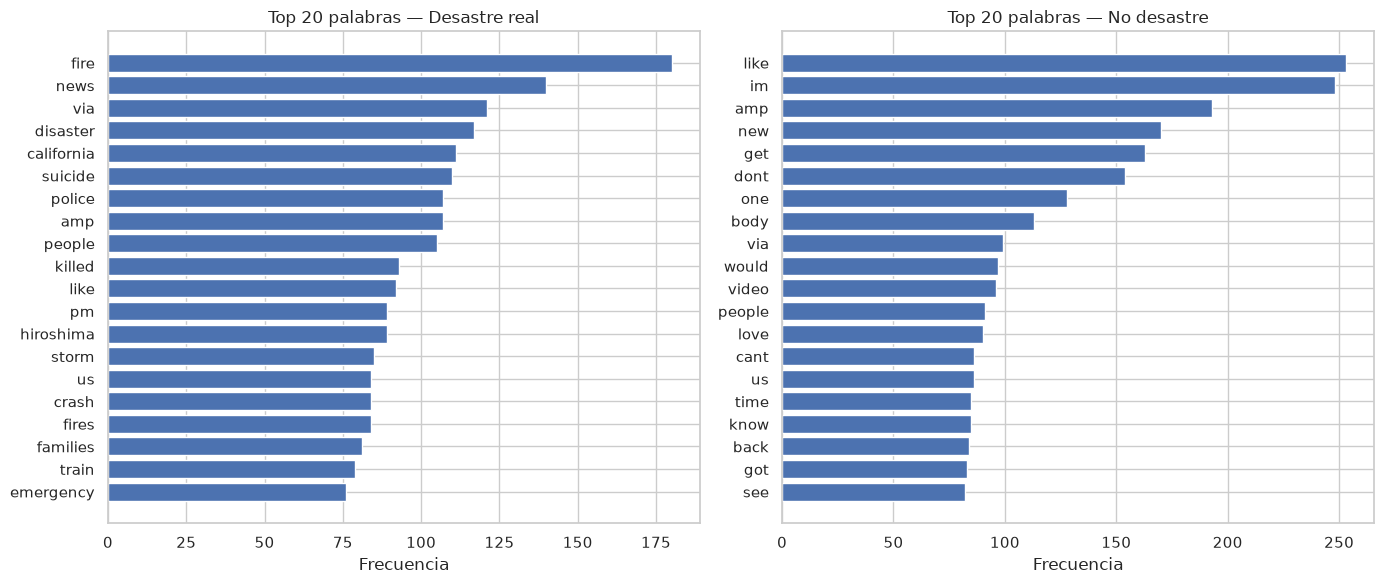

In [9]:
freq_disaster = word_frequencies(clean, target=1, top_n=20)
freq_non_disaster = word_frequencies(clean, target=0, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_top_words(freq_disaster, 'Top 20 palabras — Desastre real', ax=axes[0])
plot_top_words(freq_non_disaster, 'Top 20 palabras — No desastre', ax=axes[1])
plt.tight_layout()
plt.show()


En la clase desastre dominan sustantivos concretos de eventos reales (`fire`, `california`, `suicide`, `police`, `storm`). En la clase no-desastre aparecen palabras más genéricas y coloquiales (`like`, `im`, `new`, `get`), señal de uso metafórico o conversación cotidiana ("this song is fire", "I'm on fire today").

## 5. Nubes de palabras

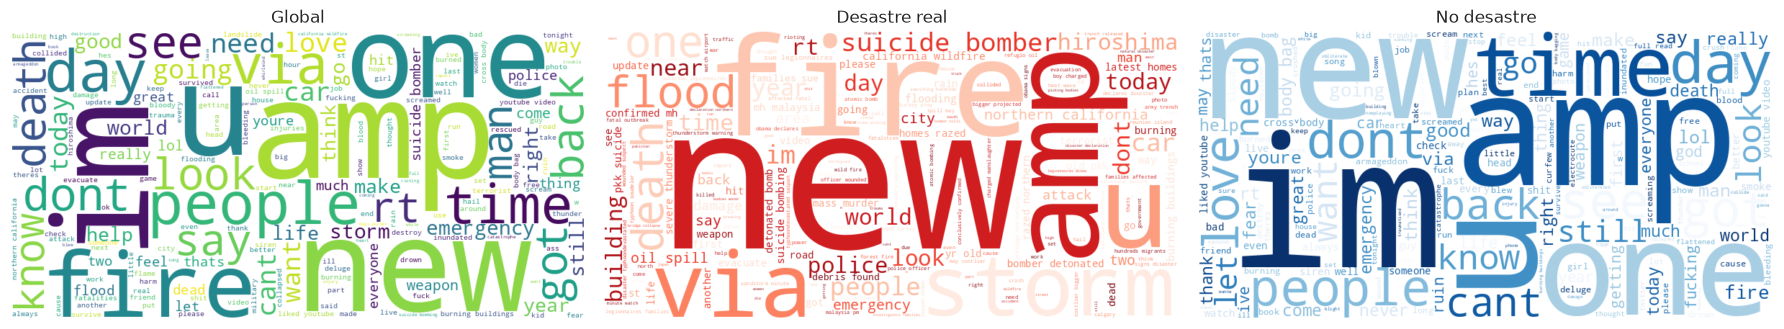

In [10]:
wc_global = make_wordcloud(clean['text'])
wc_disaster = make_wordcloud(clean[clean['target'] == 1]['text'], colormap='Reds')
wc_non_disaster = make_wordcloud(clean[clean['target'] == 0]['text'], colormap='Blues')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, wc, title in zip(axes, [wc_global, wc_disaster, wc_non_disaster],
                          ['Global', 'Desastre real', 'No desastre']):
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


Las nubes confirman visualmente el patrón del histograma: la nube de desastre está cargada de eventos concretos (`fire`, `flood`, `storm`, `emergency`), mientras que la de no-desastre muestra lenguaje más disperso y casual.

## 6. Palabras presentes en ambas categorías

In [11]:
overlap = shared_words(clean, top_n=100)
print(f"Compartidas (top-100 de cada clase): {len(overlap['shared'])}")
print(sorted(overlap['shared']))
print(f"\nExclusivas de desastre: {len(overlap['only_disaster'])}")
print(sorted(overlap['only_disaster']))
print(f"\nExclusivas de no-desastre: {len(overlap['only_non_disaster'])}")
print(sorted(overlap['only_non_disaster']))


Compartidas (top-100 de cada clase): 26
['amp', 'back', 'burning', 'could', 'dont', 'emergency', 'fire', 'first', 'get', 'im', 'like', 'man', 'may', 'new', 'news', 'one', 'people', 'rt', 'say', 'still', 'time', 'today', 'us', 'via', 'video', 'world']

Exclusivas de desastre: 74
['accident', 'army', 'atomic', 'attack', 'bomb', 'bomber', 'bombing', 'bridge', 'buildings', 'california', 'car', 'city', 'collapse', 'confirmed', 'crash', 'dead', 'death', 'debris', 'derailment', 'disaster', 'earthquake', 'evacuation', 'families', 'fatal', 'fires', 'flood', 'flooding', 'floods', 'forest', 'found', 'hiroshima', 'home', 'homes', 'injured', 'investigators', 'japan', 'killed', 'latest', 'legionnaires', 'malaysia', 'mass', 'mh', 'migrants', 'missing', 'mosque', 'near', 'northern', 'nuclear', 'obama', 'oil', 'old', 'outbreak', 'pm', 'police', 'saudi', 'severe', 'spill', 'state', 'storm', 'suicide', 'suspect', 'th', 'thunderstorm', 'train', 'two', 'war', 'warning', 'watch', 'water', 'weather', 'wildfi

Las palabras compartidas entre ambas categorías son en su mayoría términos genéricos de alta frecuencia (`like`, `new`, `via`, `get`, `people`) que no discriminan por sí solas la clase — son buenas candidatas a filtrar o a las que un modelo de bolsa de palabras dará poco peso vía TF-IDF. El poder predictivo real está en las palabras **exclusivas**: los términos exclusivos de desastre (`fire`, `flood`, `killed`, `storm`) son nombres concretos de eventos, mientras que los exclusivos de no-desastre (`lol`, `love`, `body` en sentido figurado) reflejan uso coloquial o metafórico.

## 7. Documentación de la limpieza

El texto limpio usado en las secciones 4–6 proviene de `src/limpieza.py` (ejecutado en `notebooks/preprocesamiento_y_limpieza.ipynb`), con el siguiente pipeline aplicado en orden:

1. Minúsculas (`str.lower`).
2. Eliminación de URLs (`re`).
3. Eliminación de caracteres especiales `@`, `#`, `'` (`re`).
4. Eliminación de emojis (codificación ASCII, descarta lo no-ASCII).
5. Eliminación de puntuación (`string.punctuation`).
6. Eliminación de números (`re`).
7. Eliminación de stopwords en inglés (`nltk.corpus.stopwords`).

Paquetes usados: `re`, `string` (stdlib), `nltk` (stopwords), `pandas` (manipulación de datos). Cada paso se guarda como CSV intermedio en `data/preprocessing/` para inspección, y el resultado final en `data/cleaned/train_cleaned.csv`.

## 8. Conclusiones

- El dataset está limpio estructuralmente (pocos nulos en `keyword`, `text` completo) pero `location` es demasiado ruidosa para usarse sin normalización.
- `keyword` es una señal fuerte: ciertas keywords casi siempre indican desastre real, otras casi nunca.
- El texto de tweets de desastre real es semánticamente distinto: vocabulario concreto de eventos (`fire`, `flood`, `killed`) vs. vocabulario coloquial/metafórico en tweets no-desastre.
- Los tweets de desastre tienden a ser algo más largos.
- Para el modelo de clasificación: el texto (vía TF-IDF o embeddings) y `keyword` son las variables con más señal; `location` requeriría trabajo adicional de limpieza para aportar valor.